In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
restrooms = gpd.read_file("Public Restrooms_20250720.geojson")
places = gpd.read_file("WhereIHaveBeenInNewYork.geojson")
restrooms = restrooms.to_crs("EPSG:4326")
places = places.to_crs("EPSG:4326")

In [3]:
places_points = places[places.geometry.type.eq("Point")].copy()
places_lines = places[places.geometry.type.eq("LineString")].copy()

In [ ]:
m = places_lines.explore(color="#1f77b4")
restrooms.explore(m=m, color="#d62728")
places_points.explore(m=m, column="Category", categorical=True, legend=True)
m

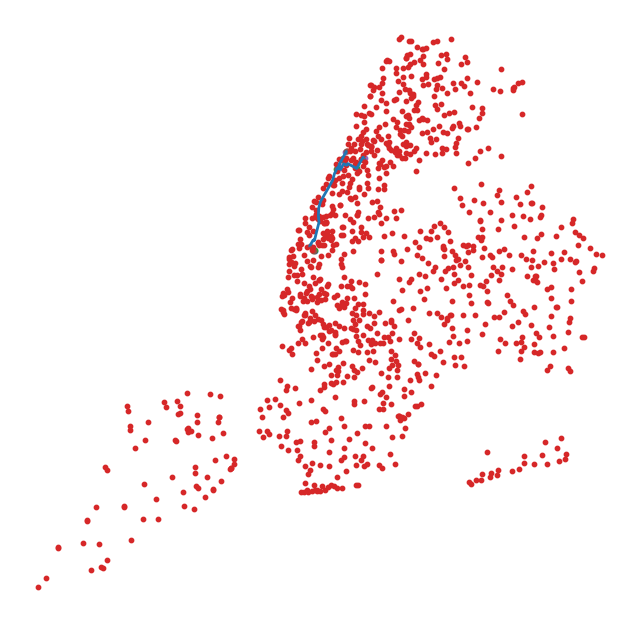

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
places_lines.plot(ax=ax, color="#1f77b4", linewidth=2)
for cat, df in places_points.groupby("Category"):
    df.plot(ax=ax, markersize=10)
restrooms.plot(ax=ax, color="#d62728", markersize=10)
ax.set_axis_off()

In [14]:
m1 = restrooms.explore(tiles="CartoDB positron", color="#d62728")
m1

In [13]:
m2 = places_lines.explore(tiles="CartoDB positron", color="#1f77b4")
places_points.explore(m=m2, column="Category", categorical=True, legend=True)
m2

In [16]:
import pandas as pd
lines_3857 = places_lines.to_crs(3857)
rest_3857 = restrooms.to_crs(3857)
d = rest_3857.geometry.apply(lambda g: g.distance(lines_3857.unary_union))
rest_dist = restrooms.copy()
rest_dist["dist_m"] = d.values
bins = [0, 50, 100, 200, 500, float("inf")]
labels = ["0-50 m", "50-100 m", "100-200 m", "200-500 m", "500+ m"]
rest_dist["dist_bin"] = pd.cut(rest_dist["dist_m"], bins=bins, labels=labels, right=False)

/var/folders/5_/99mnj5756qb94q6x_z6b80lm0000gn/T/ipykernel_5666/1975311008.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  d = rest_3857.geometry.apply(lambda g: g.distance(lines_3857.unary_union))


In [19]:
m3 = places_lines.explore(tiles="CartoDB positron", color="#1f77b4")
rest_dist.explore(m=m3, column="dist_m", cmap="Reds_r", legend=True)
m3